Installing Libraries

In [ ]:
# Or using pip:
pip install scikit-learn matplotlib pandas seaborn

# Lab 6: Algorithm Showdown
Comparing multiple ML algorithms on the same dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
# Quick exploration
print(f"Dataset shape: {X.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


In [2]:
# Split into train/test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 120
Test samples: 30


## Part 2: Compare Multiple Algorithms
We're testing four algorithms:
1. **Logistic Regression** - Linear, fast, interpretable
2. **Decision Tree** - Non-linear, visual, prone to overfitting
3. **K-Nearest Neighbors (KNN)** - Instance-based, simple, slow on large
data
4. **Random Forest** - Ensemble, powerful, less interpretable

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
# Dictionary to store our models
models = {
'Logistic Regression': LogisticRegression(max_iter=1000,
random_state=42),
'Decision Tree': DecisionTreeClassifier(random_state=42),
'K-Nearest Neighbors': KNeighborsClassifier(),
'Random Forest': RandomForestClassifier(random_state=42)
}
# Train and evaluate each model
results = {}
print("￿ Algorithm Showdown - Round 1: Accuracy\n" + "="*50)
for name, model in models.items():
# Time the training
    start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
# Store results
results[name] = {
'accuracy': accuracy,
'train_time': train_time,
'predictions': y_pred
}
print(f"{name:25} | Accuracy: {accuracy:.3f} | Time:{train_time:.4f}s")
# Find the winner
winner = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"\n￿ Winner: {winner[0]} with {winner[1]['accuracy']:.3f}accuracy!")

￿ Algorithm Showdown - Round 1: Accuracy
Random Forest             | Accuracy: 1.000 | Time:0.1192s

￿ Winner: Random Forest with 1.000accuracy!


## Part 3: Detailed Classification Metrics
Beyond accuracy - let's see precision, recall, and F1-score for each
class.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("📊 Detailed Classification Metrics\n" + "="*70)

for name, model in models.items():
    if name not in results:
        print(f"\nSkipping {name} - not found in results")
        continue

    y_pred = results[name]['predictions']

    print(f"\n{'='*70}")
    print(f"{name} - Classification Report")
    print(f"{'='*70}")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

📊 Detailed Classification Metrics

Skipping Logistic Regression - not found in results

Skipping Decision Tree - not found in results

Skipping K-Nearest Neighbors - not found in results

Random Forest - Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Part 4: Visual Comparison

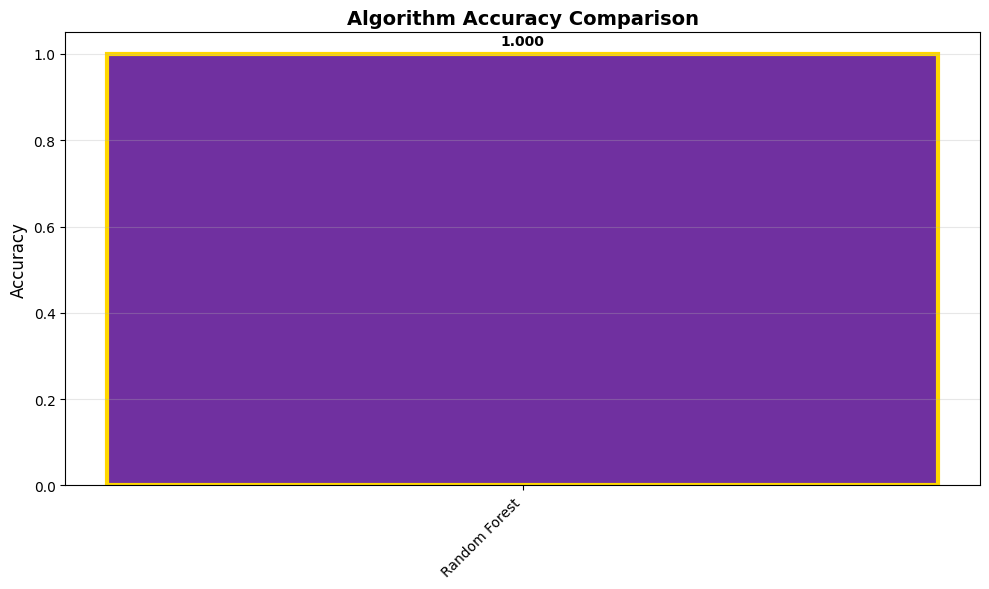

In [14]:
# Extract accuracies for plotting
algorithm_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in algorithm_names]

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    algorithm_names,
    accuracies,
    color=['#7030A0', '#9966CC', '#B399CC', '#D0BFE6']
)

# Highlight the winner
max_idx = accuracies.index(max(accuracies))
bars[max_idx].set_color('#7030A0')
bars[max_idx].set_edgecolor('gold')
bars[max_idx].set_linewidth(3)

plt.ylabel('Accuracy', fontsize=12)
plt.title('Algorithm Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (name, acc) in enumerate(zip(algorithm_names, accuracies)):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\daniy\AppData\Local\Temp\ipykernel_40680\1368887056.py:10: UserWarning: Glyph 65535 (\uffff) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\AIcybersec\cybersec_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65535 (\uffff) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


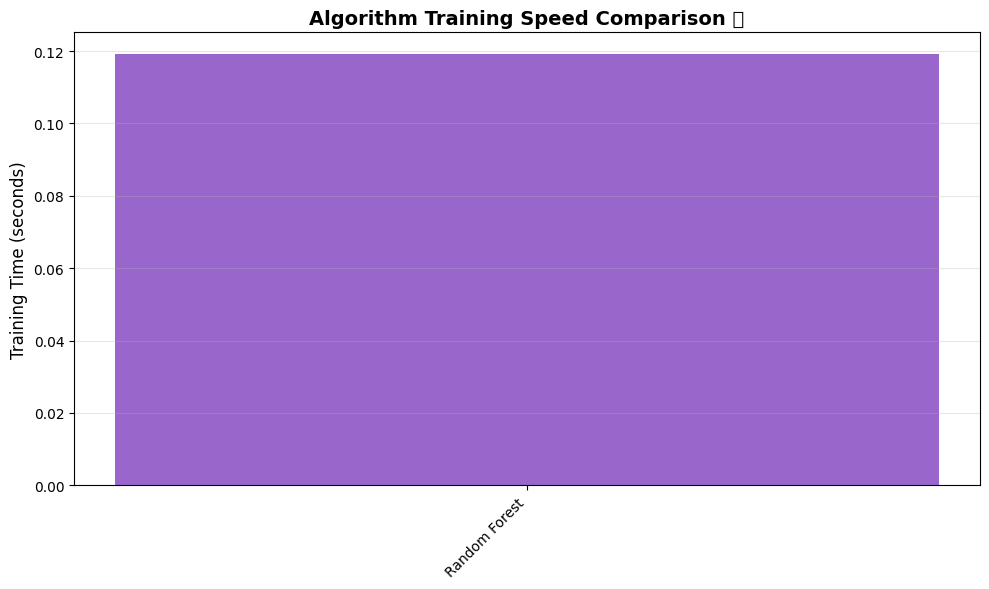

In [15]:
# Compare training times
train_times = [results[name]['train_time'] for name in algorithm_names]
plt.figure(figsize=(10, 6))
plt.bar(algorithm_names, train_times, color='#9966CC')
plt.ylabel('Training Time (seconds)', fontsize=12)
plt.title('Algorithm Training Speed Comparison ￿', fontsize=14,
fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 5: My Custom Dataset Analysis

# Dataset I chose: Wine Dataset
# Why this interests me:
# I chose the Wine dataset because it has more features than Iris and involves and classifying different wine types based on chemical properties. It is interesting because it shows how algorithms behave on a more complex built in dataset.

In [17]:
from sklearn.datasets import load_wine
import numpy as np

# Load the Wine dataset
wine = load_wine()
X_custom, y_custom = wine.data, wine.target

# Explore it
print(f"Dataset shape: {X_custom.shape}")
print(f"Feature names: {wine.feature_names}")
print(f"Target classes: {wine.target_names}")
print(f"Number of features: {X_custom.shape[1]}")
print(f"Number of classes: {len(np.unique(y_custom))}")
print(f"Class distribution: {np.bincount(y_custom)}")

Dataset shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']
Number of features: 13
Number of classes: 3
Class distribution: [59 71 48]


In [18]:
# Split your custom dataset
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_custom, y_custom, test_size=0.2, random_state=42
)

# Reinitialize models
models_custom = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Run algorithm comparison
results_custom = {}

print("🥊 CUSTOM DATASET - Algorithm Showdown\n" + "="*50)

for name, model in models_custom.items():
    start_time = time.time()
    model.fit(X_train_c, y_train_c)
    train_time = time.time() - start_time

    y_pred_c = model.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred_c)

    results_custom[name] = {
        'accuracy': accuracy,
        'train_time': train_time,
        'predictions': y_pred_c
    }

    print(f"{name:25} | Accuracy: {accuracy:.3f} | Time: {train_time:.4f}s")

winner_c = max(results_custom.items(), key=lambda x: x[1]['accuracy'])
print(f"\n🏆 Winner on custom dataset: {winner_c[0]} with {winner_c[1]['accuracy']:.3f} accuracy!")

🥊 CUSTOM DATASET - Algorithm Showdown
Logistic Regression       | Accuracy: 0.972 | Time: 0.5678s
Decision Tree             | Accuracy: 0.944 | Time: 0.0036s
K-Nearest Neighbors       | Accuracy: 0.722 | Time: 0.0013s
Random Forest             | Accuracy: 1.000 | Time: 0.1168s

🏆 Winner on custom dataset: Random Forest with 1.000 accuracy!


C:\AIcybersec\cybersec_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Compare Iris vs. Wine dataset safely
common_algorithms = [alg for alg in results.keys() if alg in results_custom.keys()]

comparison_df = pd.DataFrame({
    'Algorithm': common_algorithms,
    'Iris Accuracy': [results[k]['accuracy'] for k in common_algorithms],
    'Wine Accuracy': [results_custom[k]['accuracy'] for k in common_algorithms]
})

print("\n📊 Dataset Comparison")
print(comparison_df.to_string(index=False))


📊 Dataset Comparison
    Algorithm  Iris Accuracy  Wine Accuracy
Random Forest            1.0            1.0


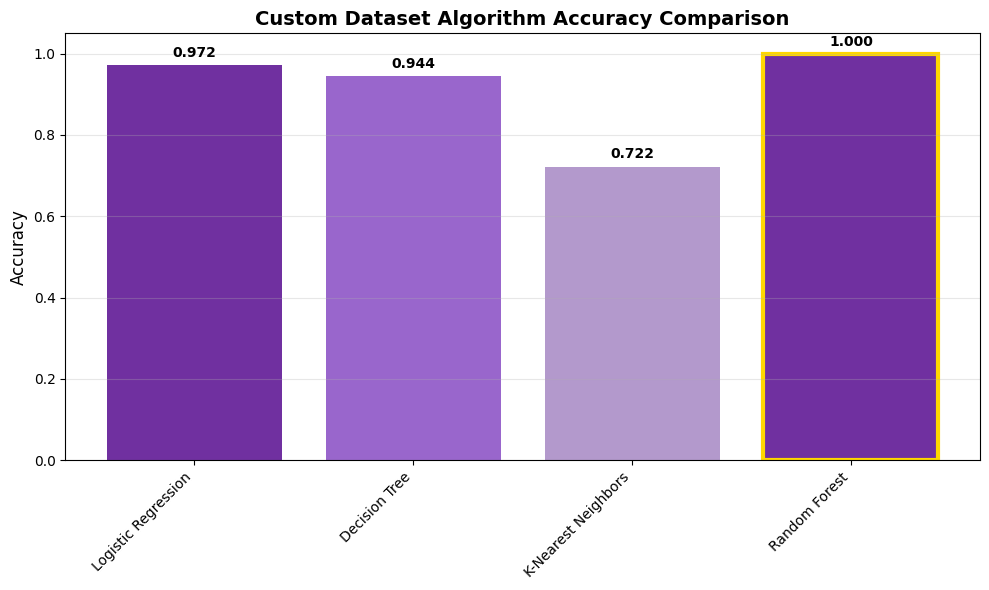

In [21]:
# Plot custom dataset accuracies
algorithm_names_custom = list(results_custom.keys())
accuracies_custom = [results_custom[name]['accuracy'] for name in algorithm_names_custom]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    algorithm_names_custom,
    accuracies_custom,
    color=['#7030A0', '#9966CC', '#B399CC', '#D0BFE6']
)

max_idx = accuracies_custom.index(max(accuracies_custom))
bars[max_idx].set_color('#7030A0')
bars[max_idx].set_edgecolor('gold')
bars[max_idx].set_linewidth(3)

plt.ylabel('Accuracy', fontsize=12)
plt.title('Custom Dataset Algorithm Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for i, acc in enumerate(accuracies_custom):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()